# 🏭 PredMaq — Pipeline Preditivo de Manutenção Industrial

**Projeto Avaliativo — Módulo 1** | Curso Desenvolvimento de IA para Análise Preditiva (T1) — Programa SCTEC / SENAI-SC

**Objetivo:** prever falhas mecânicas (`falha_maquina`: 1 = falha | 0 = normal) em equipamentos
industriais monitorados por sensores, comparando os modelos **KNN** e **Árvore de Decisão**.

---

## 📊 Fase 1 — Análise Exploratória de Dados (EDA)

Nesta fase realizamos o reconhecimento inicial da base: dimensões, tipos de dados,
resumo estatístico e visualizações que orientarão as decisões de modelagem.

In [21]:
# ============================================================
# IMPORTS E CARREGAMENTO DA BASE DE DADOS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual padrão dos gráficos
sns.set_theme(style="whitegrid")

# Carga da base com caminho RELATIVO (requisito do projeto)
df = pd.read_csv("data/manutencao_preditiva.csv")

print("=" * 60)
print("BASE DE DADOS CARREGADA COM SUCESSO")
print("=" * 60)
df.head()

BASE DE DADOS CARREGADA COM SUCESSO


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [22]:
# ============================================================
# DIMENSÕES E TIPOS DE DADOS
# ============================================================
print("=" * 60)
print(f"📐 DIMENSÕES DO DATASET")
print("=" * 60)
print(f"Número de linhas (registros): {df.shape[0]:,}")
print(f"Número de colunas (variáveis): {df.shape[1]}")

print("\n" + "=" * 60)
print("🔤 TIPOS DE DADOS DAS VARIÁVEIS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("❓ VALORES AUSENTES POR COLUNA")
print("=" * 60)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor ausente.")

📐 DIMENSÕES DO DATASET
Número de linhas (registros): 10,000
Número de colunas (variáveis): 14

🔤 TIPOS DE DADOS DAS VARIÁVEIS
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

❓ VALORES AUSENTES POR COLUNA
temperatura_ar_k          500
temperatura_processo_k    500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64


In [23]:
# ============================================================
# RESUMO ESTATÍSTICO DESCRITIVO (.describe)
# ============================================================
df.describe().round(2)

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00,9500.0,9500.00,9500.00,9500.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.00,1539.25,39.97,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.49,180.27,10.00,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.10,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1504.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1613.00,46.70,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


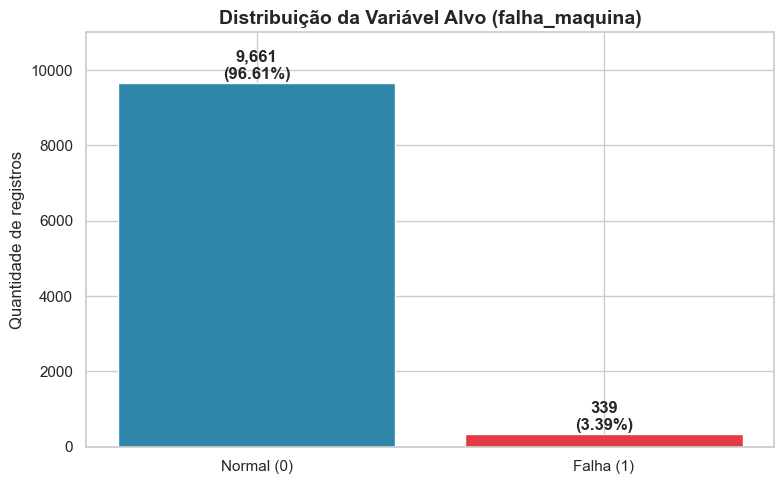

⚠️  Taxa de falhas: 3.39% — dataset FORTEMENTE desbalanceado.


In [24]:
# ============================================================
# GRÁFICO 1 — DESBALANCEAMENTO DA VARIÁVEL ALVO
# ============================================================
contagem = df["falha_maquina"].value_counts()
percentual = df["falha_maquina"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Normal (0)", "Falha (1)"], contagem.values,
              color=["#2E86AB", "#E63946"])

# Rótulos com valores absolutos e percentuais
for bar, qtd, pct in zip(bars, contagem.values, percentual.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{qtd:,}\n({pct:.2f}%)", ha="center", fontweight="bold")

ax.set_title("Distribuição da Variável Alvo (falha_maquina)", fontsize=14, fontweight="bold")
ax.set_ylabel("Quantidade de registros")
ax.set_ylim(0, 11000)
plt.tight_layout()
plt.show()

print(f"⚠️  Taxa de falhas: {percentual[1]:.2f}% — dataset FORTEMENTE desbalanceado.")

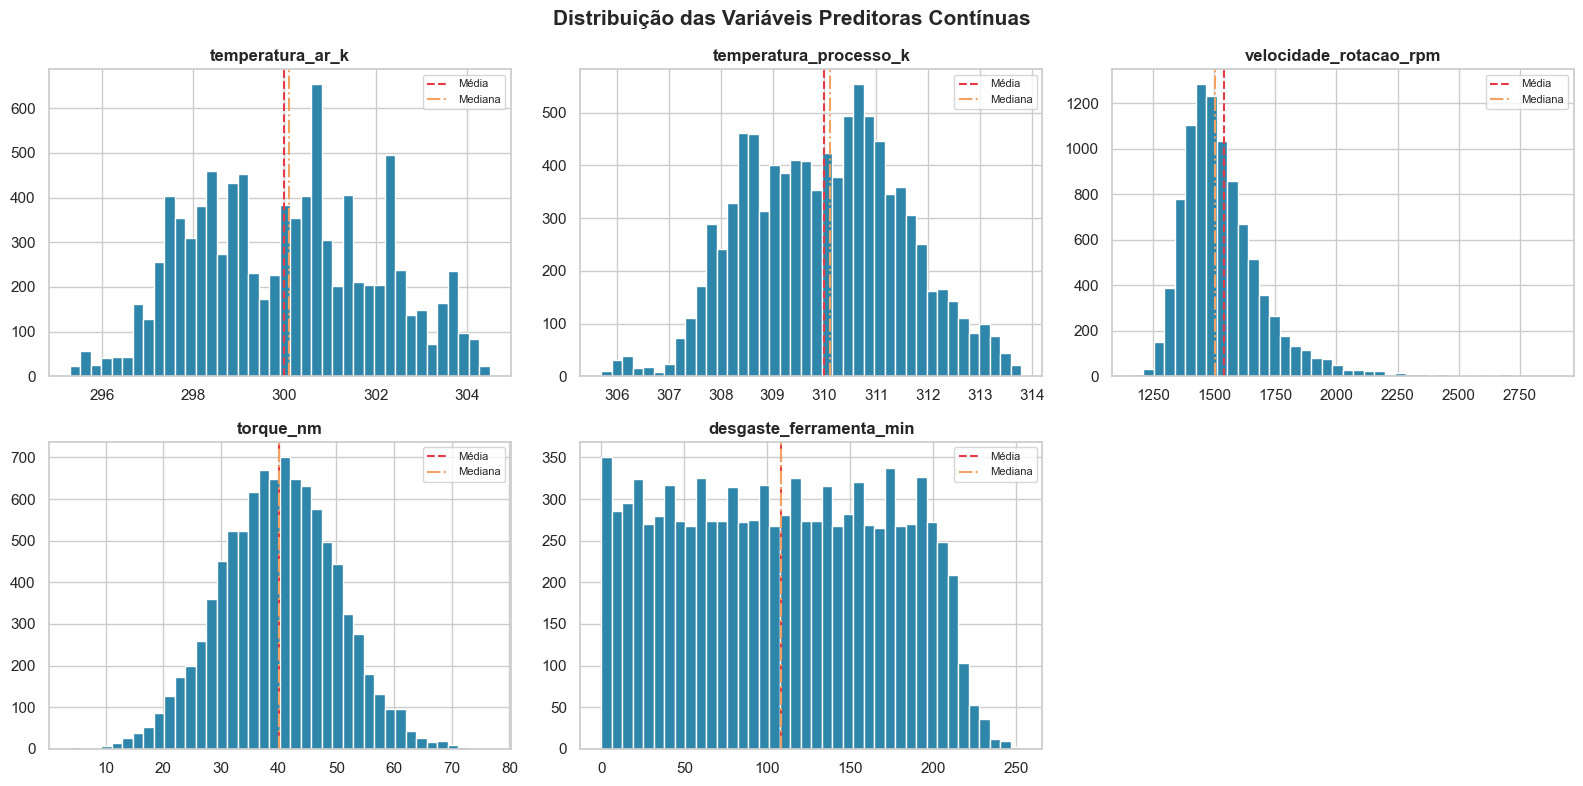

In [25]:
# ============================================================
# GRÁFICO 2 — HISTOGRAMAS DAS VARIÁVEIS PREDITORAS CONTÍNUAS
# ============================================================
variaveis_continuas = ["temperatura_ar_k", "temperatura_processo_k",
                       "velocidade_rotacao_rpm", "torque_nm", "desgaste_ferramenta_min"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_continuas):
    axes[i].hist(df[col].dropna(), bins=40, color="#2E86AB", edgecolor="white")
    axes[i].set_title(col, fontweight="bold")
    axes[i].axvline(df[col].mean(), color="#E63946", linestyle="--", label="Média")
    axes[i].axvline(df[col].median(), color="#F4A261", linestyle="-.", label="Mediana")
    axes[i].legend(fontsize=8)

axes[5].axis("off")  # desliga o sexto quadro (não utilizado)
fig.suptitle("Distribuição das Variáveis Preditoras Contínuas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

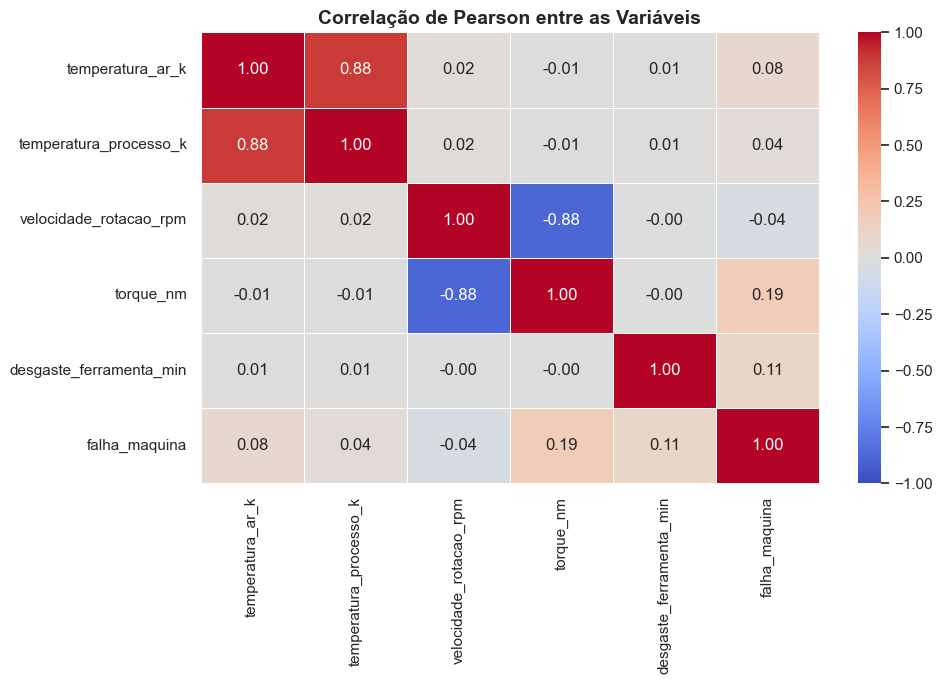

In [26]:
# ============================================================
# GRÁFICO 3 — MAPA DE CALOR (CORRELAÇÃO DE PEARSON)
# ============================================================
# Somente variáveis numéricas relevantes para a modelagem
# (exclui 'udi' por ser identificador e as colunas de motivo de falha,
#  que não serão preditoras conforme as anotações da Engenharia)
colunas_correlacao = variaveis_continuas + ["falha_maquina"]

plt.figure(figsize=(10, 7))
sns.heatmap(df[colunas_correlacao].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlação de Pearson entre as Variáveis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔎 Análise dos resultados da EDA

**1. Estrutura da base:** o dataset possui **10.000 registros e 14 colunas**. As colunas
`id_produto` e `tipo` são categóricas (texto); as demais são numéricas. Foram identificados
**500 valores ausentes** em cada uma das quatro variáveis de sensores (`temperatura_ar_k`,
`temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm`) — 5% da base —, o que
exigirá tratamento por imputação na Fase 2.

**2. Desbalanceamento severo da variável alvo:** apenas **3,39% dos registros representam
falhas** (339 casos) contra 96,61% de funcionamento normal. Isso direciona duas decisões de
modelagem: (a) a divisão treino/teste deverá usar `stratify=y` para preservar essa proporção;
e (b) será obrigatório aplicar reamostragem (SMOTE) no treino — caso contrário, um modelo
que simplesmente responda "nunca falha" atingiria 96,6% de acurácia sendo completamente inútil.

**3. Distribuições:** as temperaturas apresentam distribuições aproximadamente simétricas
(média ≈ mediana), enquanto `velocidade_rotacao_rpm` exibe assimetria à direita (cauda longa
de rotações altas), afastando a média da mediana. Essa observação fundamentará a escolha
entre média e mediana na imputação dos nulos (Fase 2).

**4. Correlações relevantes:** individualmente, as variáveis têm correlação fraca com a falha —
`torque_nm` é a mais associada (**+0,19**), seguida de `desgaste_ferramenta_min` (+0,10).
Isso indica que a falha decorre da **combinação** de fatores, e não de um sensor isolado —
justificando o uso de modelos de ML em vez de regras simples de limiar. Destacam-se ainda
duas correlações fortes **entre preditoras**: `velocidade_rotacao_rpm` × `torque_nm` (**−0,87**,
relação física esperada: mais torque, menos rotação) e `temperatura_ar_k` ×
`temperatura_processo_k` (**+0,88**). A primeira motiva a criação da variável `potencia`
(rotação × torque) na Fase 3, que sintetiza essa interação em um único atributo.

**5. Escalas distintas:** o `.describe()` mostra grandezas muito diferentes (temperaturas ≈ 300 K,
rotação ≈ 1.500 RPM, torque ≈ 40 Nm). Como o KNN é baseado em distância, será indispensável
o escalonamento via `StandardScaler` (Fase 5) — sob pena de a rotação dominar o cálculo das
distâncias e "apagar" as demais variáveis.

---
## 🧹 Fase 2 — Limpeza e Tratamento de Dados (Data Prep)

Nesta fase garantimos a qualidade da base: remoção de registros duplicados,
tratamento dos valores ausentes com justificativa estatística e análise de
outliers por meio de boxplots.

In [ ]:
# ============================================================
# IDENTIFICAÇÃO E REMOÇÃO DE LINHAS DUPLICADAS
# ============================================================
duplicados = df.duplicated().sum()
print("=" * 60)
print(f"🔍 Linhas duplicadas encontradas: {duplicados}")

df = df.drop_duplicates()
print(f"✅ Dimensões após remoção: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print("=" * 60)

In [ ]:
# ============================================================
# ANÁLISE PRÉ-IMPUTAÇÃO: MÉDIA vs MEDIANA
# ============================================================
# Antes de imputar, comparamos média e mediana de cada variável
# com nulos, para decidir tecnicamente qual medida utilizar.
colunas_com_nulos = ["temperatura_ar_k", "temperatura_processo_k",
                     "velocidade_rotacao_rpm", "torque_nm"]

print("=" * 70)
print(f"{'Variável':<28}{'Média':>12}{'Mediana':>12}{'Assimetria':>14}")
print("=" * 70)
for col in colunas_com_nulos:
    media = df[col].mean()
    mediana = df[col].median()
    assimetria = df[col].skew()
    print(f"{col:<28}{media:>12.2f}{mediana:>12.2f}{assimetria:>14.3f}")
print("=" * 70)
print("\n📌 Regra prática: |assimetria| próxima de 0 → distribuição simétrica;")
print("   valores acima de ~0,5 indicam assimetria relevante (cauda longa).")

### 📝 Justificativa técnica: imputação pela MEDIANA

Optamos pela **mediana** como estratégia de imputação dos valores ausentes, por dois motivos:

1. **Robustez a outliers e assimetria:** a variável `velocidade_rotacao_rpm` apresenta
assimetria positiva relevante (cauda longa à direita, visível no histograma da EDA e
confirmada pelo coeficiente de assimetria). Nesses casos, a média é "puxada" pelos valores
extremos e deixa de representar o registro típico — enquanto a mediana permanece estável.

2. **Consistência metodológica:** para as variáveis aproximadamente simétricas
(temperaturas), média e mediana são praticamente idênticas — ou seja, usar a mediana
nelas não traz prejuízo. Adotar a mediana para todas as colunas garante um critério
único, seguro e defensável para o pipeline.

In [ ]:
# ============================================================
# IMPUTAÇÃO DOS VALORES AUSENTES PELA MEDIANA
# ============================================================
for col in colunas_com_nulos:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"✅ {col:<28} → nulos preenchidos com a mediana ({mediana:.2f})")

print("\n" + "=" * 60)
print(f"❓ Total de nulos restantes no dataset: {df.isnull().sum().sum()}")
print("=" * 60)

In [ ]:
# ============================================================
# BOXPLOTS — IDENTIFICAÇÃO DE OUTLIERS (MÉTODO DE TUKEY)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_continuas):
    sns.boxplot(y=df[col], ax=axes[i], color="#2E86AB")
    axes[i].set_title(col, fontweight="bold")

    # Contagem de outliers pelo critério de Tukey (1,5 x IQR)
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f"Outliers (Tukey): {n_outliers}")

axes[5].axis("off")
fig.suptitle("Boxplots das Variáveis Explicativas — Análise de Outliers",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔎 Análise dos outliers

Os boxplots (critério de Tukey: valores além de 1,5 × IQR das cercas) mostram outliers
concentrados em `velocidade_rotacao_rpm` e `torque_nm`. **Decidimos mantê-los na base**,
pois em manutenção preditiva os valores extremos de operação (picos de rotação, torque
anômalo) **são justamente os regimes associados às falhas** — removê-los descartaria
exatamente a informação que o modelo precisa aprender. Além disso, a imputação pela
mediana e o uso da Árvore de Decisão (naturalmente robusta a outliers) mitigam seus
efeitos indesejados; para o KNN, o escalonamento da Fase 5 reduzirá o impacto das
magnitudes extremas.